# Compare Continuous and Cumulative Low-Till Duration Effects: Corn
# Fig 3 (a)-(b)
This notebook reads the 1999-2023 low-till duration model outputs for corn and compares two duration definitions:

- continuous low-till duration, measured as uninterrupted low-till spell length
- cumulative low-till duration, measured as accumulated low-till years

For each definition, the notebook compares the linear duration coefficient with the duration-bin estimates, then plots both definitions on common axes.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

CROP = "corn"
CROP_LABEL = "Corn"
PANEL_LABEL = "(a)"

start = Path.cwd().resolve()
for candidate in [start, *start.parents]:
    if (candidate / "output_linear_1999_2023").exists():
        root = candidate
        break
else:
    raise FileNotFoundError("Could not find output_linear_1999_2023 from the current working directory.")

output_root = root / "output_linear_1999_2023"

result_specs = {
    "Continuous low-till duration": {
        "linear_terms": output_root / "1_corn_linear_field_year_high_till_initially/corn_ols_field_year_terms.csv",
        "bin_terms": output_root / "1_corn_duration_bins_field_year_high_till_initially/corn_fe_duration_bins_clean_climate_terms.csv",
        "linear_sample": output_root / "1_corn_linear_field_year_high_till_initially/corn_sample_counts.csv",
        "bin_sample": output_root / "1_corn_duration_bins_field_year_high_till_initially/corn_fe_duration_bins_clean_climate_sample_counts.csv",

        "line_color": "#d62728",
        "fill_color": "#f4a3a3",

        "marker": "o",
        "offset": -0.25,
    },
    "Cumulative low-till duration": {
        "linear_terms": output_root / "1_corn_linear_field_year_high_till_initially_cumulative/corn_ols_field_year_terms.csv",
        "bin_terms": output_root / "1_corn_duration_bins_field_year_high_till_initially_cumulative/corn_fe_duration_bins_clean_climate_terms.csv",
        "linear_sample": output_root / "1_corn_linear_field_year_high_till_initially_cumulative/corn_sample_counts.csv",
        "bin_sample": output_root / "1_corn_duration_bins_field_year_high_till_initially_cumulative/corn_fe_duration_bins_clean_climate_sample_counts.csv",
        
        "line_color": "#1f77b4",
        "fill_color": "#9ecae1",

        "marker": "s",
        "offset": 0.25,
    },
}

paths = pd.DataFrame(
    [
        {"duration_definition": definition, "file_type": key, "path": str(path.relative_to(root))}
        for definition, spec in result_specs.items()
        for key, path in spec.items()
        if isinstance(path, Path)
    ]
)
paths


,duration_definition,file_type,path
0,Continuous low-till duration,linear_terms,output_linear_1999_2023/1_corn_linear_field_ye...
1,Continuous low-till duration,bin_terms,output_linear_1999_2023/1_corn_duration_bins_f...
2,Continuous low-till duration,linear_sample,output_linear_1999_2023/1_corn_linear_field_ye...
3,Continuous low-till duration,bin_sample,output_linear_1999_2023/1_corn_duration_bins_f...
4,Cumulative low-till duration,linear_terms,output_linear_1999_2023/1_corn_linear_field_ye...
5,Cumulative low-till duration,bin_terms,output_linear_1999_2023/1_corn_duration_bins_f...
6,Cumulative low-till duration,linear_sample,output_linear_1999_2023/1_corn_linear_field_ye...
7,Cumulative low-till duration,bin_sample,output_linear_1999_2023/1_corn_duration_bins_f...


## Prepare Estimates

Convert log-point estimates and confidence intervals to percent yield effects so the two duration definitions can be compared on the same scale.


In [2]:
bin_map = {
    "till_duration_bin::1_4": {"label": "1-4", "xmin": 1, "xmax": 4, "xmid": 2.5},
    "till_duration_bin::5_9": {"label": "5-9", "xmin": 5, "xmax": 9, "xmid": 7.0},
    "till_duration_bin::10_14": {"label": "10-14", "xmin": 10, "xmax": 14, "xmid": 12.0},
    "till_duration_bin::15_19": {"label": "15-19", "xmin": 15, "xmax": 19, "xmid": 17.0},
    "till_duration_bin::20+": {"label": "20+", "xmin": 20, "xmax": 25, "xmid": 22.5},
}

def pct_effect(estimate):
    return (np.exp(estimate) - 1) * 100

def read_linear_result(definition, spec):
    terms = pd.read_csv(spec["linear_terms"])
    row = terms.loc[terms["term"] == "low_till_duration"].iloc[0]
    sample = pd.read_csv(spec["linear_sample"])
    sample_row = sample.loc[sample["sample"] == "estimation_sample_after_weather_join"].iloc[0]
    beta = row["estimate"]
    se = row["std_error"]
    years = np.linspace(0, 25, 300)

    summary = {
        "duration_definition": definition,
        "estimate": beta,
        "std_error": se,
        "pct_per_year": pct_effect(beta),
        "pct_low": pct_effect(beta - 1.96 * se),
        "pct_high": pct_effect(beta + 1.96 * se),
        "p_value": row["p_value"],
        "observations": int(sample_row["observations"]),
        "fields": int(sample_row["fields"]),
        "counties": int(sample_row["counties"]),
        "years": int(sample_row["years"]),
    }
    curve = pd.DataFrame({
        "duration_definition": definition,
        "years": years,
        "pct": pct_effect(beta * years),
        "pct_low": pct_effect((beta - 1.96 * se) * years),
        "pct_high": pct_effect((beta + 1.96 * se) * years),
    })
    return summary, curve

def read_bin_result(definition, spec):
    terms = pd.read_csv(spec["bin_terms"])
    rows = terms[terms["term"].str.startswith("till_duration_bin::")].copy()
    missing = set(bin_map) - set(rows["term"])
    if missing:
        raise ValueError(f"Missing duration-bin estimates for {definition}: {sorted(missing)}")

    for key in ["label", "xmin", "xmax", "xmid"]:
        rows[key] = rows["term"].map(lambda term: bin_map[term][key])
    rows["duration_definition"] = definition
    rows["pct"] = pct_effect(rows["estimate"])
    rows["pct_low"] = pct_effect(rows["estimate"] - 1.96 * rows["std_error"])
    rows["pct_high"] = pct_effect(rows["estimate"] + 1.96 * rows["std_error"])
    return rows.sort_values("xmid").reset_index(drop=True)

def read_bin_sample(definition, spec):
    sample = pd.read_csv(spec["bin_sample"]).copy()
    sample["duration_definition"] = definition
    sample["label"] = sample["till_duration_bin"].astype(str).replace({"0": "0"})
    return sample[["duration_definition", "label", "observations", "fields", "counties", "acres"]]

linear_summaries = []
linear_curves = []
bin_effects = []
bin_samples = []

for definition, spec in result_specs.items():
    summary, curve = read_linear_result(definition, spec)
    linear_summaries.append(summary)
    linear_curves.append(curve)
    bin_effects.append(read_bin_result(definition, spec))
    bin_samples.append(read_bin_sample(definition, spec))

linear_summary = pd.DataFrame(linear_summaries)
linear_curves = pd.concat(linear_curves, ignore_index=True)
bin_effects = pd.concat(bin_effects, ignore_index=True)
bin_samples = pd.concat(bin_samples, ignore_index=True)

linear_summary_display = linear_summary[
    ["duration_definition", "pct_per_year", "pct_low", "pct_high", "p_value", "observations", "fields", "counties", "years"]
].copy()
linear_summary_display[["pct_per_year", "pct_low", "pct_high"]] = linear_summary_display[
    ["pct_per_year", "pct_low", "pct_high"]
].round(3)

linear_summary_display


,duration_definition,pct_per_year,pct_low,pct_high,p_value,observations,fields,counties,years
0,Continuous low-till duration,0.199,0.146,0.251,4.409200e-13,23391541,3381656,794,25
1,Cumulative low-till duration,0.180,0.128,0.232,2.698245e-11,44667232,3891224,796,25


In [3]:
bin_display = bin_effects[
    ["duration_definition", "label", "estimate", "std_error", "pct", "pct_low", "pct_high", "p_value"]
].copy()
bin_display[["estimate", "std_error", "pct", "pct_low", "pct_high"]] = bin_display[
    ["estimate", "std_error", "pct", "pct_low", "pct_high"]
].round(3)

bin_display


,duration_definition,label,estimate,std_error,pct,pct_low,pct_high,p_value
0,Continuous low-till duration,1-4,0.009,0.002,0.929,0.618,1.241,6.421818e-09
1,Continuous low-till duration,5-9,0.020,0.002,2.001,1.510,2.494,2.986355e-15
2,Continuous low-till duration,10-14,0.030,0.003,3.063,2.390,3.740,1.352659e-18
3,Continuous low-till duration,15-19,0.034,0.004,3.432,2.596,4.275,1.474626e-15
4,Continuous low-till duration,20+,0.041,0.005,4.193,3.172,5.224,1.186831e-15
5,Cumulative low-till duration,1-4,0.002,0.001,0.249,0.032,0.468,2.507663e-02
6,Cumulative low-till duration,5-9,0.010,0.002,1.041,0.664,1.419,7.338580e-08
7,Cumulative low-till duration,10-14,0.018,0.003,1.831,1.296,2.369,2.806470e-11
8,Cumulative low-till duration,15-19,0.023,0.003,2.339,1.645,3.038,5.194289e-11
9,Cumulative low-till duration,20+,0.033,0.004,3.323,2.431,4.222,3.782612e-13


In [4]:
beta_by_definition = linear_summary.set_index("duration_definition")["estimate"]

model_contrast = bin_effects[["duration_definition", "label", "xmid", "pct", "pct_low", "pct_high"]].copy()
model_contrast["linear_pct_at_bin_mid"] = model_contrast.apply(
    lambda row: pct_effect(beta_by_definition.loc[row["duration_definition"]] * row["xmid"]),
    axis=1,
)
model_contrast["binned_minus_linear_midpoint"] = model_contrast["pct"] - model_contrast["linear_pct_at_bin_mid"]
model_contrast_display = model_contrast[
    ["duration_definition", "label", "pct", "linear_pct_at_bin_mid", "binned_minus_linear_midpoint"]
].copy()
model_contrast_display[["pct", "linear_pct_at_bin_mid", "binned_minus_linear_midpoint"]] = model_contrast_display[
    ["pct", "linear_pct_at_bin_mid", "binned_minus_linear_midpoint"]
].round(3)

model_contrast_display


,duration_definition,label,pct,linear_pct_at_bin_mid,binned_minus_linear_midpoint
0,Continuous low-till duration,1-4,0.929,0.497,0.432
1,Continuous low-till duration,5-9,2.001,1.398,0.603
2,Continuous low-till duration,10-14,3.063,2.409,0.654
3,Continuous low-till duration,15-19,3.432,3.430,0.002
4,Continuous low-till duration,20+,4.193,4.564,-0.371
5,Cumulative low-till duration,1-4,0.249,0.450,-0.200
6,Cumulative low-till duration,5-9,1.041,1.264,-0.223
7,Cumulative low-till duration,10-14,1.831,2.177,-0.346
8,Cumulative low-till duration,15-19,2.339,3.098,-0.758
9,Cumulative low-till duration,20+,3.323,4.120,-0.798


In [5]:
definition_delta = bin_effects.pivot(index="label", columns="duration_definition", values="pct").loc[
    ["1-4", "5-9", "10-14", "15-19", "20+"]
]
definition_delta["Cumulative minus continuous"] = (
    definition_delta["Cumulative low-till duration"] - definition_delta["Continuous low-till duration"]
)
definition_delta.round(3)


duration_definition,Continuous low-till duration,Cumulative low-till duration,Cumulative minus continuous
label,,,
1-4,0.929,0.249,-0.679
5-9,2.001,1.041,-0.960
10-14,3.063,1.831,-1.231
15-19,3.432,2.339,-1.093
20+,4.193,3.323,-0.871


In [6]:
sample_display = linear_summary[
    ["duration_definition", "observations", "fields", "counties", "years"]
].rename(columns={"observations": "linear_observations", "fields": "linear_fields"})

bin_sample_display = bin_samples.copy()
bin_sample_display["acres_million"] = bin_sample_display["acres"] / 1_000_000
bin_sample_display = bin_sample_display[
    ["duration_definition", "label", "observations", "fields", "counties", "acres_million"]
]

print("Linear model estimation samples")
display(sample_display)
print("Duration-bin model samples by bin")
display(bin_sample_display.round({"acres_million": 1}))


Linear model estimation samples


,duration_definition,linear_observations,linear_fields,counties,years
0,Continuous low-till duration,23391541,3381656,794,25
1,Cumulative low-till duration,44667232,3891224,796,25


Duration-bin model samples by bin


,duration_definition,label,observations,fields,counties,acres_million
0,Continuous low-till duration,0,12638442,2799183,783,2374.0
1,Continuous low-till duration,1_4,4277038,2427480,793,702.4
2,Continuous low-till duration,5_9,2657031,1159262,784,382.2
3,Continuous low-till duration,10_14,1924193,793666,776,279.0
4,Continuous low-till duration,15_19,1340885,577624,760,197.4
5,Continuous low-till duration,20+,553952,308837,727,76.1
6,Cumulative low-till duration,0,12638442,2799183,783,2374.0
7,Cumulative low-till duration,1_4,12856765,3223515,794,2306.2
8,Cumulative low-till duration,5_9,9292296,2956228,793,1497.1
9,Cumulative low-till duration,10_14,6005766,2282670,781,925.9


## Within-Definition Comparison

Each panel recreates the original linear-versus-bin comparison, once for continuous duration and once for cumulative duration.


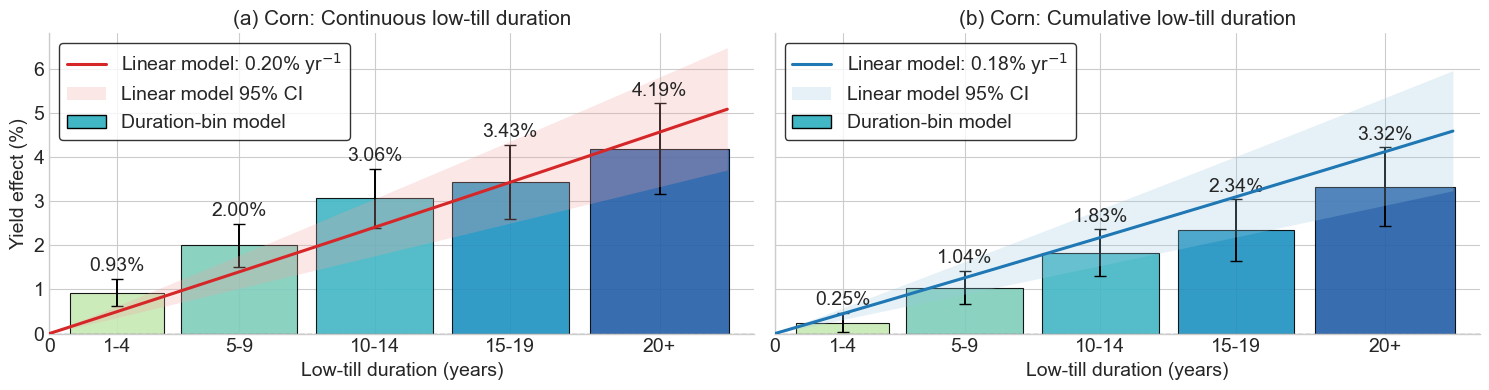

In [8]:
def plot_definition_panel(ax, definition, title):
    spec = result_specs[definition]
    rows = bin_effects[bin_effects["duration_definition"] == definition]
    curve = linear_curves[linear_curves["duration_definition"] == definition]
    summary = linear_summary.set_index("duration_definition").loc[definition]
    colors = ["#c7e9b4", "#7fcdbb", "#41b6c4", "#1d91c0", "#225ea8"]
    widths = (rows["xmax"] - rows["xmin"] + 1).to_numpy() * 0.86
    yerr = np.vstack([
        rows["pct"] - rows["pct_low"],
        rows["pct_high"] - rows["pct"],
    ])

    bars = ax.bar(
        rows["xmid"],
        rows["pct"],
        width=widths,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        zorder=1,
    )
    ax.errorbar(
        rows["xmid"],
        rows["pct"],
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1.4,
        capsize=4,
        zorder=2,
    )
    ax.fill_between(
        curve["years"].to_numpy(),
        curve["pct_low"].to_numpy(),
        curve["pct_high"].to_numpy(),
        color=spec["fill_color"],
        alpha=0.26,
        linewidth=0,
        zorder=3,
    )
    ax.plot(curve["years"], curve["pct"], color=spec["line_color"], linewidth=2.2, zorder=4)

    for bar, (_, row) in zip(bars, rows.iterrows()):
        ax.text(
            row["xmid"],
            row["pct_high"] + 0.08,
            f"{row['pct']:.2f}%",
            ha="center",
            va="bottom",
            fontsize=14,
        )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1.0)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Low-till duration (years)", fontsize=14)
    ax.set_xlim(0, 26)
    ax.set_xticks([0, 2.5, 7, 12, 17, 22.5])
    ax.set_xticklabels(["0", "1-4", "5-9", "10-14", "15-19", "20+"])
    ax.tick_params(axis="both", labelsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        handles=[
            Line2D([0], [0], color=spec["line_color"], lw=2.2, label=rf"Linear model: {summary['pct_per_year']:.2f}% yr$^{{-1}}$"),
            Patch(facecolor=spec["fill_color"], edgecolor="none", alpha=0.26, label="Linear model 95% CI"),
            Patch(facecolor=colors[2], edgecolor="black", label="Duration-bin model"),
        ],
        loc="upper left",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fontsize=14,
    )

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
plot_definition_panel(axes[0], "Continuous low-till duration", "(a) Corn: Continuous low-till duration")
plot_definition_panel(axes[1], "Cumulative low-till duration", "(b) Corn: Cumulative low-till duration")
axes[0].set_ylabel("Yield effect (%)", fontsize=14)
#fig.suptitle(f"{CROP_LABEL} Yield Effects: Linear and Binned Duration Models", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()
